# Imports & Reproducibility

In [15]:
# Este bloque importa librerías y configura semillas/determinismo para que el experimento del trading bot sea reproducible (mismos resultados en cada corrida, incluso con GPU).
import numpy as np, pandas as pd, random, collections
import yfinance as yf
import torch, torch.nn as nn, torch.optim as optim
from dataclasses import dataclass
import vectorbt as vbt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
try:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)
except Exception:
    pass

# Download Close Prices

In [16]:
TICKER = "NVDA"  # change as desired
raw = yf.download([TICKER], period="12y", interval="1d", auto_adjust=False)
close_df = raw["Close"].dropna(how="all").ffill().dropna()
px = close_df[TICKER].copy()  # pandas.Series of Close
assert px.notna().all()

[*********************100%***********************]  1 of 1 completed


# Feature Engineering

In [17]:
# Este código construye un conjunto de indicadores técnicos estandarizados (features) a partir de precios, listos para alimentar un trading bot (ML/RL) de forma estable y sin valores inválidos.

def make_features(px: pd.Series) -> pd.DataFrame:
    ret = np.log(px/px.shift(1))
    vol20 = ret.rolling(20).std()
    vol60 = ret.rolling(60).std()
    sma10 = px.rolling(10).mean()/px - 1.0
    sma50 = px.rolling(50).mean()/px - 1.0
    mom10 = px/px.shift(10) - 1.0
    mom20 = px/px.shift(20) - 1.0
    chg = px.diff()
    up = chg.clip(lower=0).rolling(14).mean()
    dn = (-chg.clip(upper=0)).rolling(14).mean()
    rsi = 100 - 100/(1 + (up/dn))

    F = pd.concat([ret.rename("ret"), vol20, vol60, sma10, sma50, mom10, mom20, rsi], axis=1)
    F.columns = ["ret","vol20","vol60","sma10","sma50","mom10","mom20","rsi"]
    F = F.replace([np.inf, -np.inf], np.nan).dropna()

    # rolling z-score for stability (except returns)
    for c in ["vol20","vol60","sma10","sma50","mom10","mom20","rsi"]:
        m = F[c].rolling(252, min_periods=100).mean()
        s = F[c].rolling(252, min_periods=100).std()
        F[c] = (F[c]-m)/s
    return F.dropna()

F = make_features(px)
assert "ret" in F and F.notna().all().all()

# Train/Val/Test Split

In [18]:
# Este bloque divide las features en train/validation/test respetando el orden temporal (80/10/10) para evitar leakage y asegura que las fechas estén ordenadas.
n = len(F)
i1, i2 = int(n*0.8), int(n*0.9)  # 80/10/10 split
train = F.iloc[:i1]
val   = F.iloc[i1:i2]
test  = F.iloc[i2:]
for part in (train, val, test):
    assert part.index.is_monotonic_increasing

# Full TradingEnv

In [19]:
# Define una estructura simple para agrupar parámetros del entorno (fees, slippage, límite de pasos)
@dataclass
class EnvConfig:
    fee_bps: float = 1.0   # comisión en basis points (1 bp = 0.01%)
    slip_bps: float = 2.0  # slippage en basis points
    max_steps: int | None = None  # si se define, limita la duración del episodio

class TradingEnv:
    def __init__(self, F: pd.DataFrame, cfg: EnvConfig):
        # Validaciones básicas: el entorno necesita la columna 'ret' (retorno log)
        if "ret" not in F.columns:
            raise ValueError("F must contain 'ret' column (log returns). Build features first.")
        if len(F) < 2:
            raise ValueError("F must have at least 2 rows.")

        # Guarda features y configuración
        self.F = F
        self.cfg = cfg

        # Columnas de observación: todas menos 'ret'
        # (el agente NO ve el retorno futuro; solo ve indicadores/estado)
        self.obs_cols = [c for c in F.columns if c != "ret"]

        # Plantilla para observación final cuando el episodio termina
        # (misma dimensión que obs normal, pero llena con ceros)
        self._template_obs = np.nan_to_num(F.iloc[1][self.obs_cols].values.astype(np.float32))

        # Inicializa el estado del entorno
        self.reset()

    def reset(self):
        # Reinicia el episodio:
        # t=1 para que exista ret[t] y también podamos usar ret con una posición previa
        self.t = 1

        # Posición actual del agente:
        # -1 = short, 0 = flat, +1 = long
        self.pos = 0

        # Bandera de fin de episodio
        self.done = False

        # Equity normalizada (1.0 = capital inicial)
        self.equity = 1.0

        # Devuelve la observación inicial
        return self._obs()

    def _obs(self):
        # Construye la observación del tiempo t:
        # vector de features (sin 'ret'), convertido a float32 y sin NaNs
        row = self.F.iloc[self.t]
        return np.nan_to_num(row[self.obs_cols].values.astype(np.float32))

    def step(self, action: int):
        # Ejecuta un paso de simulación dado un action del agente

        # Si el episodio ya terminó, no se puede avanzar
        if self.done:
            raise RuntimeError("Episode finished; call reset().")

        # Guarda la posición previa para:
        # - calcular el PnL del periodo con esa exposición
        # - calcular costos si hubo cambio de posición
        prev_pos = self.pos

        # Mapea action a posición:
        # - action -1 → short
        # - action  0 → flat
        # - action  1 → long
        # Cualquier otro valor cae a 0 (flat)
        self.pos = {-1: -1, 0: 0, 1: 1}.get(action, 0)

        # Retorno del paso:
        # usa el retorno log de ese día multiplicado por la posición ANTERIOR
        # (importante: el trade se aplica "después" para evitar lookahead)
        r = float(self.F.iloc[self.t]["ret"]) * prev_pos

        # traded=1 si cambió la posición (hay transacción); 0 si se mantuvo
        traded = int(self.pos != prev_pos)

        # Costos (comisión + slippage) solo si operaste:
        # bps → fracción dividiendo entre 1e4
        cost = traded * ((self.cfg.fee_bps + self.cfg.slip_bps) / 1e4)

        # Recompensa final del paso = retorno con posición previa - costos
        r_after = r - cost

        # Actualiza equity multiplicativamente (crecimiento compuesto)
        self.equity *= (1.0 + r_after)

        # Avanza el tiempo
        self.t += 1

        # Condición de término:
        # - si max_steps está definido y se alcanzó
        # - o si se llegó al final del DataFrame
        if (self.cfg.max_steps and self.t >= self.cfg.max_steps) or self.t >= len(self.F) - 1:
            self.done = True

        # Observación siguiente:
        # - si terminó, devuelve un vector de ceros (misma forma)
        # - si no, devuelve la obs del nuevo tiempo
        obs = self._obs() if not self.done else np.zeros_like(self._template_obs)

        # Info adicional útil para logging/backtesting
        info = {"equity": self.equity, "ret": r_after, "pos": self.pos}

        # Devuelve:
        # obs: siguiente estado
        # r_after: recompensa del paso
        # done: fin del episodio
        # info: métricas extra
        return obs, r_after, self.done, info


# DQN: Actions & Model

In [20]:
# Este bloque define una red neuronal Q-Network que, a partir del estado del mercado, estima el valor (Q-value) de cada acción posible: short, flat o long.

# Acciones discretas del agente:
# -1 = short, 0 = flat, 1 = long
ACTIONS = [-1, 0, 1]

class QNet(nn.Module):
    def __init__(self, in_dim: int, hidden=64, n_actions=3):
        super().__init__()

        # ------------------------------------------------------------
        # Red neuronal fully-connected (MLP)
        #
        # in_dim     : número de features del estado (observación)
        # hidden     : tamaño de las capas ocultas
        # n_actions  : número de acciones posibles (3: short/flat/long)
        #
        # La red aprende una función Q(s, a):
        #   entrada  -> estado del mercado
        #   salida   -> valor esperado de cada acción
        # ------------------------------------------------------------
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),  # capa que proyecta el estado al espacio oculto
            nn.ReLU(),                  # no linealidad

            nn.Linear(hidden, hidden),  # segunda capa oculta
            nn.ReLU(),                  # no linealidad

            nn.Linear(hidden, n_actions)  # salida: Q-values para cada acción
        )

    def forward(self, x):
        # ------------------------------------------------------------
        # Forward pass:
        # recibe un estado x y devuelve un vector:
        # [Q(short), Q(flat), Q(long)]
        # ------------------------------------------------------------
        return self.net(x)


# DQN Training Loop

In [21]:
# Este código entrena un trading bot con Deep Q-Learning (DQN): interactúa con el entorno (comprar/vender/flat), guarda experiencias en un replay buffer, y actualiza una red neuronal para que aprenda qué acción maximiza la recompensa futura.

def dqn_train(env: TradingEnv, epochs=6, steps_per_epoch=6000,
              batch_size=64, gamma=0.99, lr=1e-3,
              eps_start=1.0, eps_end=0.05, eps_decay_steps=30000,
              target_sync=1000):
    # ------------------------------------------------------------
    # Entrenamiento DQN para trading:
    # - q: red principal que aprende Q(s,a)
    # - tgt: red objetivo (target network) para estabilizar entrenamiento
    # - replay buffer: almacena transiciones y entrena con muestras aleatorias
    # - epsilon-greedy: explora al inicio y explota después
    # ------------------------------------------------------------

    # Selecciona dispositivo (GPU si está disponible)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Dimensión de la observación (número de features)
    obs_dim = len(env.obs_cols)

    # Red Q principal
    q = QNet(obs_dim).to(device)

    # Red objetivo (inicia igual que q)
    tgt = QNet(obs_dim).to(device)
    tgt.load_state_dict(q.state_dict())

    # Optimizador
    opt = optim.Adam(q.parameters(), lr=lr)

    # Replay buffer: almacena hasta 100k transiciones (s, a, r, s', done)
    buf = collections.deque(maxlen=100_000)

    # Contador global de pasos (sirve para el decay de epsilon y sincronización)
    step_count = 0

    # Loss robusta (Huber loss): menos sensible a outliers que MSE
    loss_fn = nn.SmoothL1Loss()

    # ------------------------------------------------------------
    # Función epsilon (exploración):
    # - empieza en eps_start (1.0 = mucho random)
    # - baja linealmente hacia eps_end
    # ------------------------------------------------------------
    def epsilon():
        return max(
            eps_end,
            eps_start - (eps_start - eps_end) * step_count / eps_decay_steps
        )

    # ------------------------------------------------------------
    # Loop de entrenamiento por epochs
    # ------------------------------------------------------------
    for ep in range(epochs):
        # Reinicia el entorno al inicio de cada epoch
        obs = env.reset()
        done = False

        # Itera hasta terminar episodio o alcanzar el límite de pasos del epoch
        while not done and step_count < steps_per_epoch * (ep + 1):
            step_count += 1

            # --------------------------------------------------------
            # SELECCIÓN DE ACCIÓN (epsilon-greedy)
            # --------------------------------------------------------
            if random.random() < epsilon():
                # Explorar: acción aleatoria
                a_idx = random.randrange(len(ACTIONS))
            else:
                # Explotar: acción con mayor Q-value estimado por la red
                with torch.no_grad():
                    qv = q(
                        torch.tensor(obs, dtype=torch.float32, device=device)
                        .unsqueeze(0)  # agrega dimensión batch
                    )
                    a_idx = int(torch.argmax(qv).item())

            # Ejecuta la acción en el entorno
            # ACTIONS[a_idx] traduce índice -> {-1,0,1}
            obs2, r, done, _ = env.step(ACTIONS[a_idx])

            # Guarda transición en replay buffer
            buf.append((obs, a_idx, r, obs2, done))

            # Avanza al siguiente estado
            obs = obs2

            # Si no hay suficientes muestras todavía, continúa recolectando experiencia
            if len(buf) < batch_size:
                continue

            # --------------------------------------------------------
            # MUESTREO DE MINIBATCH DESDE EL REPLAY BUFFER
            # (rompe correlaciones temporales y estabiliza aprendizaje)
            # --------------------------------------------------------
            b_obs, b_a, b_r, b_obs2, b_done = zip(*random.sample(buf, batch_size))

            # Convierte minibatch a tensores
            b_obs  = torch.tensor(b_obs,  dtype=torch.float32, device=device)
            b_a    = torch.tensor(b_a,    dtype=torch.int64,   device=device)
            b_r    = torch.tensor(b_r,    dtype=torch.float32, device=device)
            b_obs2 = torch.tensor(b_obs2, dtype=torch.float32, device=device)
            b_done = torch.tensor(b_done, dtype=torch.bool,    device=device)

            # --------------------------------------------------------
            # CÁLCULO DE Q(s,a) ACTUAL
            # q(b_obs) devuelve Q-values para todas las acciones
            # gather selecciona el Q-value de la acción tomada b_a
            # --------------------------------------------------------
            q_sa = q(b_obs).gather(1, b_a.view(-1, 1)).squeeze(1)

            # --------------------------------------------------------
            # CÁLCULO DEL TARGET (Bellman)
            # target = r + gamma * max_a' Q_tgt(s', a')   si no terminal
            # --------------------------------------------------------
            with torch.no_grad():
                q_next = tgt(b_obs2).max(1)[0]  # máximo Q-value del siguiente estado
                target = b_r + (~b_done).float() * gamma * q_next

            # Loss entre predicción y target
            loss = loss_fn(q_sa, target)

            # Backprop + actualización de parámetros
            opt.zero_grad()
            loss.backward()

            # Clipping de gradientes para evitar explosión
            nn.utils.clip_grad_norm_(q.parameters(), 1.0)

            opt.step()

            # --------------------------------------------------------
            # Sincronización periódica de la red objetivo
            # (la target network se actualiza cada target_sync pasos)
            # --------------------------------------------------------
            if step_count % target_sync == 0:
                tgt.load_state_dict(q.state_dict())

    # Devuelve la red entrenada (política aprendida)
    return q


# Train DQN

In [22]:
train_env = TradingEnv(train, EnvConfig(fee_bps=1.0, slip_bps=2.0))
q_model = dqn_train(train_env)

# Greedy Policy Rollout

In [ ]:
# Este bloque ejecuta (“hace rollout”) la política aprendida por el DQN sobre datos fuera de muestra, generando la secuencia de acciones de trading (short/flat/long) que el bot tomaría en el periodo de test
@torch.no_grad()
def rollout_policy(F_split: pd.DataFrame, q_model: nn.Module,
                   fee_bps=1.0, slip_bps=2.0) -> pd.Series:
    # ------------------------------------------------------------
    # Ejecuta la política entrenada SIN aprendizaje (solo inferencia)
    # @torch.no_grad(): desactiva gradientes → más rápido y seguro
    # ------------------------------------------------------------

    # Detecta el dispositivo (CPU/GPU) donde vive el modelo
    device = next(q_model.parameters()).device

    # Crea un entorno de trading usando el split dado (ej. test)
    # con los mismos costos usados en entrenamiento
    env = TradingEnv(F_split, EnvConfig(fee_bps=fee_bps, slip_bps=slip_bps))

    # Reinicia el entorno y obtiene la primera observación
    obs = env.reset()
    done = False

    # Listas para guardar:
    # - acciones tomadas
    # - índices temporales correspondientes
    acts, idxs = [], []

    # ------------------------------------------------------------
    # Loop de rollout: avanza paso a paso hasta terminar el episodio
    # ------------------------------------------------------------
    while not done:
        # Convierte la observación a tensor y agrega dimensión batch
        x = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)

        # Forward pass del Q-network:
        # obtiene Q-values para [short, flat, long]
        a_idx = int(torch.argmax(q_model(x)).item())

        # Traduce índice → acción real (-1, 0, +1)
        a = ACTIONS[a_idx]

        # Guarda acción y timestamp actual
        acts.append(a)
        idxs.append(F_split.index[env.t])

        # Ejecuta la acción en el entorno
        obs, _, done, _ = env.step(a)

    # Devuelve una Serie temporal con las acciones del bot
    return pd.Series(acts, index=idxs, name="action")


# ------------------------------------------------------------
# Rollout del bot entrenado sobre el conjunto de test
# ------------------------------------------------------------
actions_test = rollout_policy(test, q_model)


# Convert Actions → Signals

In [ ]:
# ------------------------------------------------------------
# 1) Alinear acciones del bot con precios reales
# ------------------------------------------------------------

# Índice temporal de las acciones generadas por el bot
idx = actions_test.index

# Reindexa la serie de precios (px) a esas fechas
# y elimina fechas donde no haya precio
prices = px.reindex(idx).dropna()

# Actualiza el índice final solo con fechas válidas en precios
idx = prices.index


# ------------------------------------------------------------
# 2) Acciones actuales y previas
# ------------------------------------------------------------

# Acción actual del bot en cada fecha:
# -1 = short, 0 = flat, 1 = long
act = actions_test.reindex(idx).fillna(0).astype(int)

# Acción del día anterior (para detectar cambios de estado)
prev = act.shift(1).fillna(0).astype(int)


# ------------------------------------------------------------
# 3) Construcción de señales LONG
# ------------------------------------------------------------

# Entrada long:
# - ayer no estabas long (flat o short)
# - hoy pasas a long
long_entries = ((prev <= 0) & (act == 1)).astype(bool) \
    .reindex(idx, fill_value=False)

# Salida long:
# - ayer estabas long
# - hoy ya no estás long (flat o short)
long_exits = ((prev == 1) & (act <= 0)).astype(bool) \
    .reindex(idx, fill_value=False)


# ------------------------------------------------------------
# 4) Construcción de señales SHORT
# ------------------------------------------------------------

# Entrada short:
# - ayer no estabas short (flat o long)
# - hoy pasas a short
short_entries = ((prev >= 0) & (act == -1)).astype(bool) \
    .reindex(idx, fill_value=False)

# Salida short:
# - ayer estabas short
# - hoy ya no estás short (flat o long)
short_exits = ((prev == -1) & (act >= 0)).astype(bool) \
    .reindex(idx, fill_value=False)


# ------------------------------------------------------------
# 5) Corrección del primer día
# ------------------------------------------------------------

# Evita abrir posiciones en la primera fila
# (no hay estado previo válido)
if len(idx) > 0:
    long_entries.iloc[0] = False
    short_entries.iloc[0] = False


# ------------------------------------------------------------
# 6) Sanity check: todos los índices deben coincidir
# ------------------------------------------------------------

assert prices.index.equals(long_entries.index) \
    and prices.index.equals(long_exits.index) \
    and prices.index.equals(short_entries.index) \
    and prices.index.equals(short_exits.index)


# Backtest with vectorbt

In [28]:
fees = 0.0001  # 1 bp
slip = 0.0002  # 2 bps

pf = vbt.Portfolio.from_signals(
    close=prices,
    entries=long_entries, exits=long_exits,
    short_entries=short_entries, short_exits=short_exits,
    fees=fees, slippage=slip, freq="D"
)

# Version-Proof Stats

In [29]:
stats = pf.stats()
trade_stats = pf.trades.stats()  # may be empty if no trades

summary = pd.Series({
    "Total Return [%]": stats.get("Total Return [%]"),
    "Sharpe Ratio": stats.get("Sharpe Ratio"),
    "Max Drawdown [%]": stats.get("Max Drawdown [%]"),
    "Win Rate [%]": trade_stats.get("Win Rate [%]", float("nan")),
    "Exposure [%]": stats.get("Exposure [%]", stats.get("Exposure Time [%]", float("nan")))
})
print(summary)

Total Return [%]    14.643052
Sharpe Ratio         0.596325
Max Drawdown [%]    35.965075
Win Rate [%]        48.648649
Exposure [%]              NaN
dtype: float64


# Visual Checks

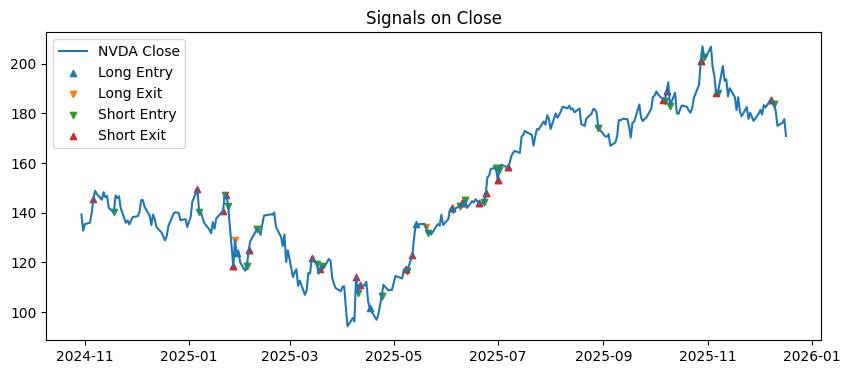

In [27]:
pf.plot().show()  # interactive equity curve (requires plotly)

import matplotlib.pyplot as plt
m_idx = prices.index
plt.figure(figsize=(10,4))
plt.plot(m_idx, prices.values, label=f"{TICKER} Close")
plt.scatter(m_idx[long_entries], prices[long_entries], marker="^", s=20, label="Long Entry")
plt.scatter(m_idx[long_exits], prices[long_exits], marker="v", s=20, label="Long Exit")
plt.scatter(m_idx[short_entries], prices[short_entries], marker="v", s=20, label="Short Entry")
plt.scatter(m_idx[short_exits], prices[short_exits], marker="^", s=20, label="Short Exit")
plt.legend(); plt.title("Signals on Close"); plt.show()